In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
#Cargar el dataset principal ya unido con la tabla maestra
df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")
archivo_excel = "Tablas maestras bases GRD.xlsx"
xls = pd.ExcelFile(archivo_excel)
maestra_df = pd.read_excel(xls, sheet_name="IR - GRD")
df['GRD'] = df['GRD'].astype(str)
maestra_df['IR- GRD'] = maestra_df['IR- GRD'].astype(str)
df_merged = df.merge(maestra_df, how='left', left_on='GRD', right_on='IR- GRD')

#Calcular valores nulos por columna
valores_nulos = df_merged.isnull().sum()

#Crear un DataFrame con los resultados
tabla_nulos = pd.DataFrame({
  "Columna": valores_nulos.index,
  "Valores nulos": valores_nulos.values
})

#Filtrar columnas con nulos y ordenar de mayor a menor
tabla_nulos = tabla_nulos[tabla_nulos["Valores nulos"] > 0]
tabla_nulos = tabla_nulos.sort_values(by="Valores nulos", ascending=False)

# Mostrar tabla
print(" Tabla de valores nulos por columna:")
print(tabla_nulos.to_string(index=False))


 Tabla de valores nulos por columna:
   Columna  Valores nulos
   IR- GRD          14561
Unnamed: 1          14561


In [ ]:
# i. Estudio de la calidad de los datos
# Correctitud (valores fuera de rango o inesperados)


# 📁 Cargar el dataset principal ya unido con la tabla maestra
df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")
archivo_excel = "Tablas maestras bases GRD.xlsx"
xls = pd.ExcelFile(archivo_excel)
maestra_df = pd.read_excel(xls, sheet_name="IR - GRD")
df['GRD'] = df['GRD'].astype(str)
maestra_df['IR- GRD'] = maestra_df['IR- GRD'].astype(str)
df_merged = df.merge(maestra_df, how='left', left_on='GRD', right_on='IR- GRD')

# Revisar nombre real de columna de descripción del GRD en la tabla maestra
print("\n Columnas en tabla maestra:")
print(maestra_df.columns)

#  1. EDAD EN AÑOS: valores fuera del rango lógico (0 a 120)
edad_erronea = df_merged[(df_merged['Edad en años'] < 0) | (df_merged['Edad en años'] > 120)]
print(f"\n Edades fuera de rango (0-120): {len(edad_erronea)} registros")

#  2. SEXO: valores inválidos (esperado: 1=Hombre, 2=Mujer o descripciones conocidas)
valores_validos_sexo = ['1', '2', 'Masculino', 'Femenino', 'M', 'F','Hombre','Mujer']
sexo_invalidos = df_merged[~df_merged['Sexo (Desc)'].astype(str).isin(valores_validos_sexo)]
print(f" Registros con sexo inválido: {len(sexo_invalidos)}")


grd_no_encontrados = df_merged[df_merged['GRD'].isnull()]
print(f" GRD no encontrados en tabla maestra: {len(grd_no_encontrados)} registros")

#  Mostrar algunas muestras si hay registros erróneos
if len(edad_erronea) > 0:
    print("\n Ejemplo de edades fuera de rango:")
    print(edad_erronea[['Edad en años', 'Sexo (Desc)', 'GRD']].head())

if len(sexo_invalidos) > 0:
    print("\n Ejemplo de sexo inválido:")
    print(sexo_invalidos[['Sexo (Desc)', 'GRD', 'Edad en años']].head())



 Columnas en tabla maestra:
Index(['IR- GRD', 'Unnamed: 1'], dtype='object')

 Edades fuera de rango (0-120): 1 registros
 Registros con sexo inválido: 0
 GRD no encontrados en tabla maestra: 0 registros

 Ejemplo de edades fuera de rango:
      Edad en años Sexo (Desc)  \
2588           121       Mujer   

                                                    GRD  
2588  224121 - MH OTROS FACTORES QUE INFLUYEN EN EL ...  


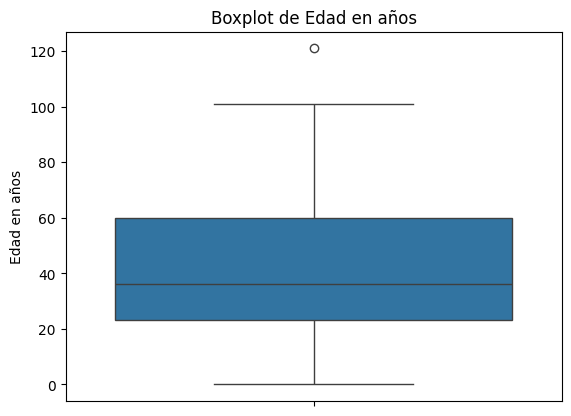

In [ ]:
# outliers

import seaborn as sns
import matplotlib.pyplot as plt


#  Cargar el dataset principal ya unido con la tabla maestra
df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")
archivo_excel = "Tablas maestras bases GRD.xlsx"
xls = pd.ExcelFile(archivo_excel)
maestra_df = pd.read_excel(xls, sheet_name="IR - GRD")
df['GRD'] = df['GRD'].astype(str)
maestra_df['IR- GRD'] = maestra_df['IR- GRD'].astype(str)
df_merged = df.merge(maestra_df, how='left', left_on='GRD', right_on='IR- GRD')

# Edad
sns.boxplot(data=df_merged, y='Edad en años')
plt.title("Boxplot de Edad en años")
plt.show()



📈 Clasificación - Métricas por clase:
                                                                                        precision    recall  f1-score   support

                   041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC       0.55      0.70      0.62        60
                           044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC       0.87      0.70      0.77       110
                                             061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE       0.99      1.00      0.99        73
                                             071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA       0.95      0.98      0.97       100
                                                  134161 - MH TRASTORNOS DEL ANTEPARTO       0.85      0.86      0.85        98
                                                                   146101 - PH CESÁREA       0.76      0.87      0.81       254
                                                              146

<ipython-input-6-60742b1d22a5>:77: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x1000 with 0 Axes>

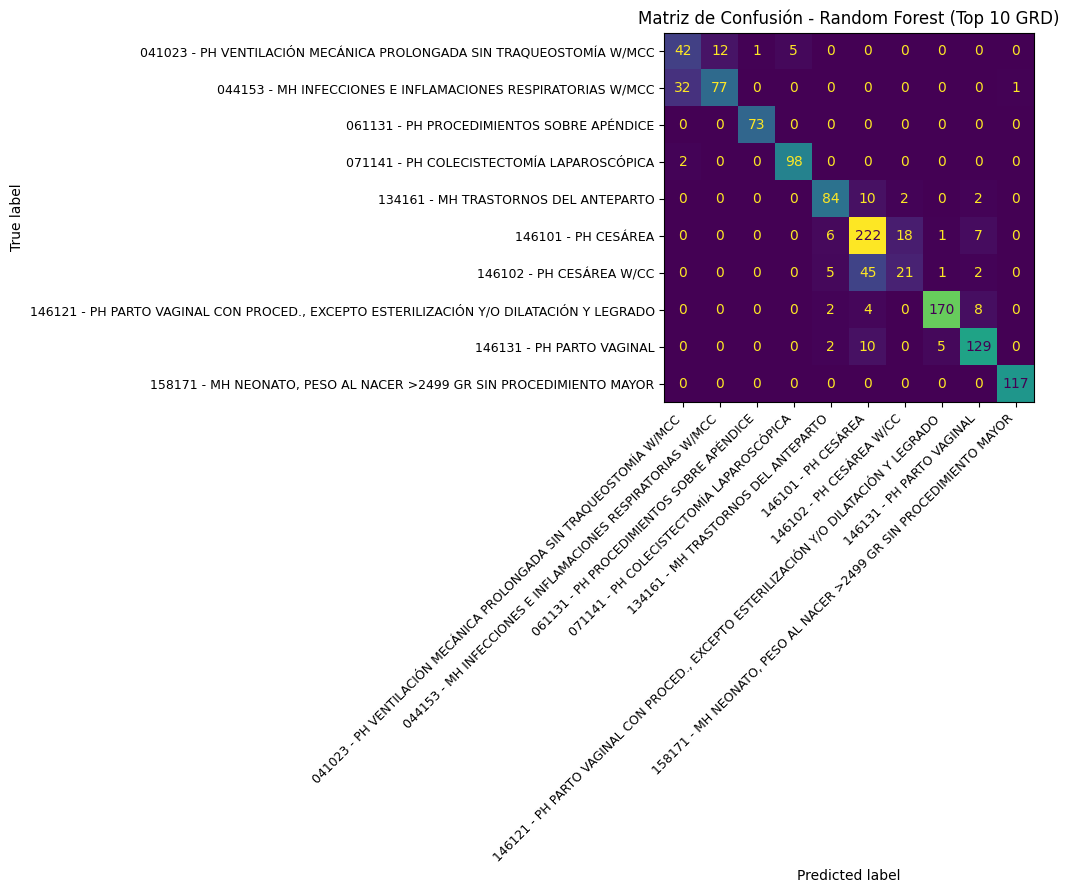

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Cargar datos
df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")

# Variables de entrada
vars_entrada = [
    "Edad en años",
    "Sexo (Desc)",
    "Diag 01 Principal (cod+des)",
    "Diag 02 Secundario (cod+des)"
]

# Filtrar top 10 GRD más frecuentes
top_grd = df["GRD"].value_counts().nlargest(10).index
df = df[df["GRD"].isin(top_grd)]

# Preparar datos
df_modelo = df[vars_entrada + ["GRD"]].dropna()
df_modelo["Sexo"] = df_modelo["Sexo (Desc)"].map({"Hombre": 0, "Mujer": 1})

le_diag1 = LabelEncoder()
le_diag2 = LabelEncoder()
df_modelo["Diag 01 Principal"] = le_diag1.fit_transform(df_modelo["Diag 01 Principal (cod+des)"].astype(str))
df_modelo["Diag 02 Secundario"] = le_diag2.fit_transform(df_modelo["Diag 02 Secundario (cod+des)"].astype(str))

# Etiquetas
le_grd = LabelEncoder()
y = le_grd.fit_transform(df_modelo["GRD"])
X = df_modelo[["Edad en años", "Sexo", "Diag 01 Principal", "Diag 02 Secundario"]]

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar modelo
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Métricas
print("📈 Clasificación - Métricas por clase:")
clases_presentes = np.unique(y_test)
nombres_presentes = le_grd.inverse_transform(clases_presentes)

# OPCIONAL: Abreviar etiquetas para mejor visualización
# nombres_presentes = [s.split(" - ")[0] for s in le_grd.inverse_transform(clases_presentes)]

print(classification_report(
    y_test,
    clf.predict(X_test),
    labels=clases_presentes,
    target_names=nombres_presentes
))

# Matriz de confusión
cm = confusion_matrix(y_test, clf.predict(X_test), labels=clases_presentes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_presentes)

plt.figure(figsize=(12, 10))
disp.plot(
    cmap="viridis",
    values_format='d',
    xticks_rotation=45,
    colorbar=False
)

# Ajustar etiquetas
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title("Matriz de Confusión - Random Forest (Top 10 GRD)")
plt.tight_layout()
plt.show()


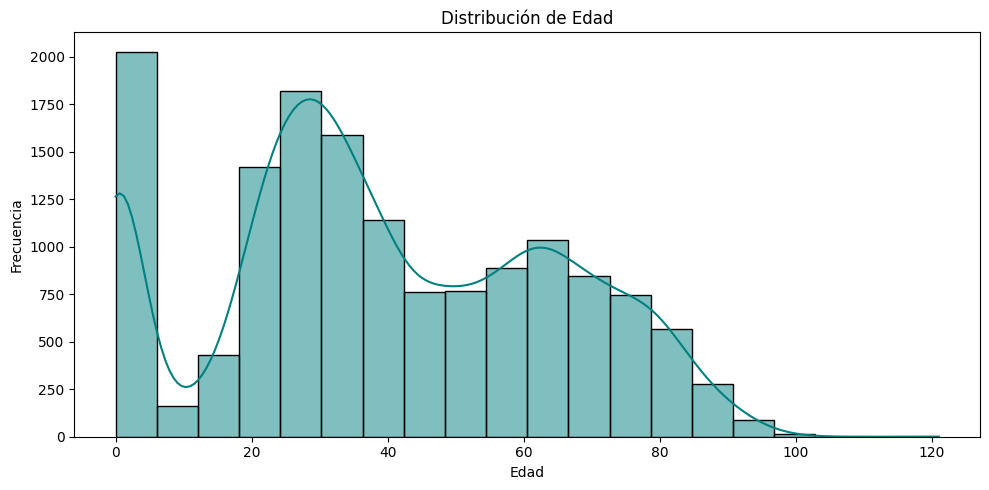

<ipython-input-7-4c3bd33d2e19>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Sexo (Desc)", y="Edad en años", data=df_merged, palette="Set2")


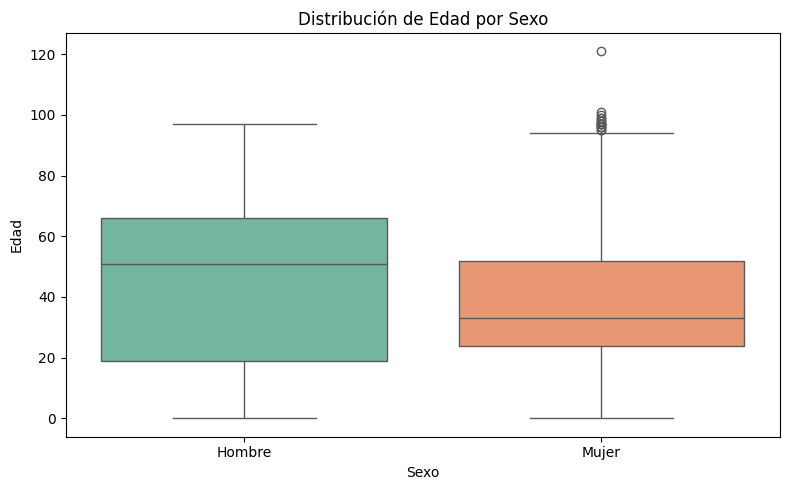

<ipython-input-7-4c3bd33d2e19>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="GRD", y="Edad en años", data=df_top_10, order=top_10_grd, palette="pastel")


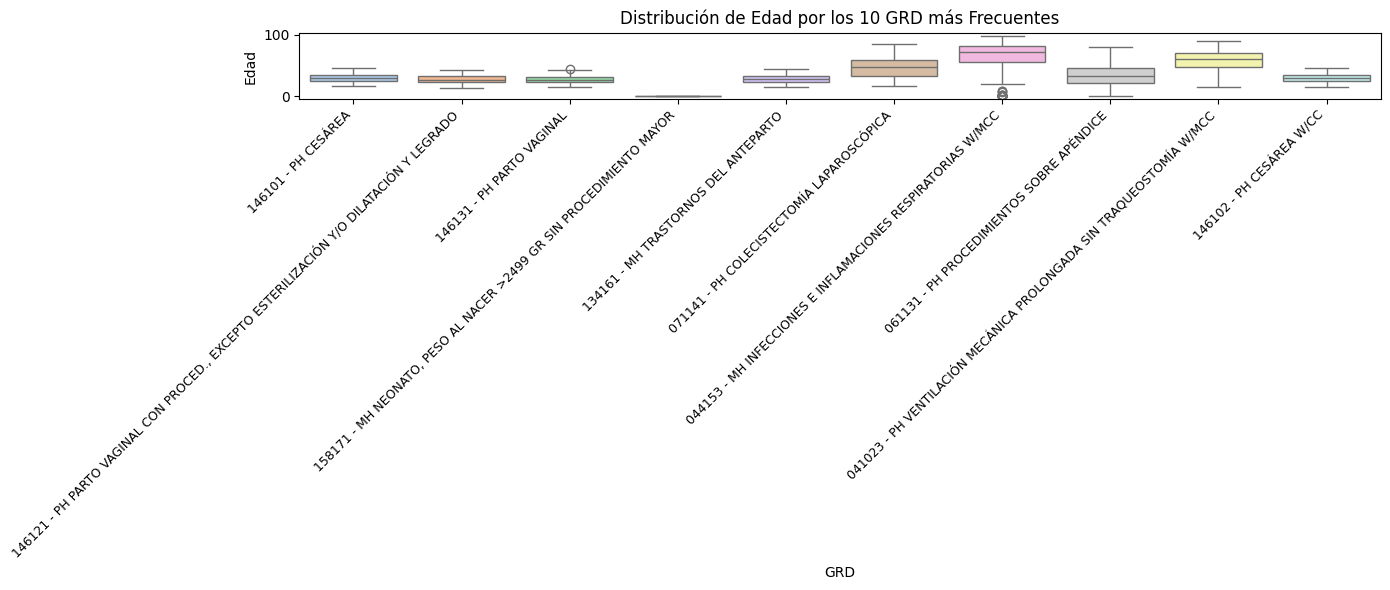

<ipython-input-7-4c3bd33d2e19>:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="GRD", data=df_top_10, order=top_10_grd, palette="muted")


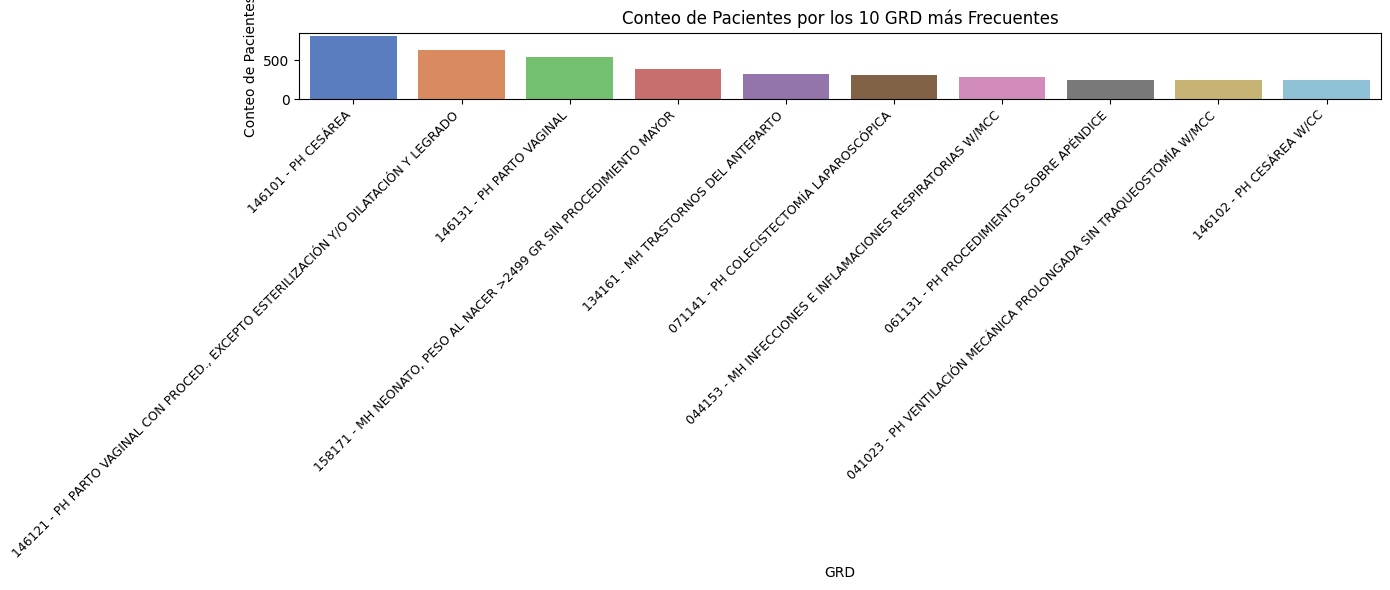

<ipython-input-7-4c3bd33d2e19>:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sexo (Desc)", data=df_merged, palette="coolwarm")


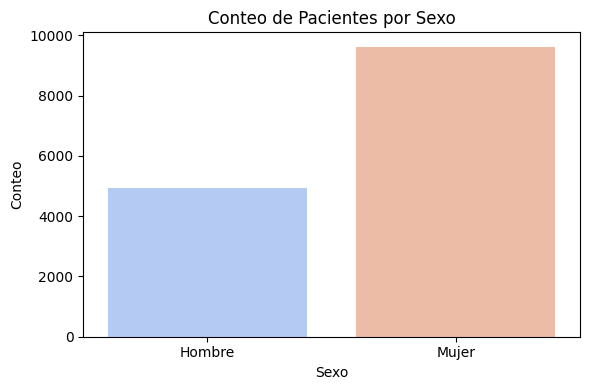

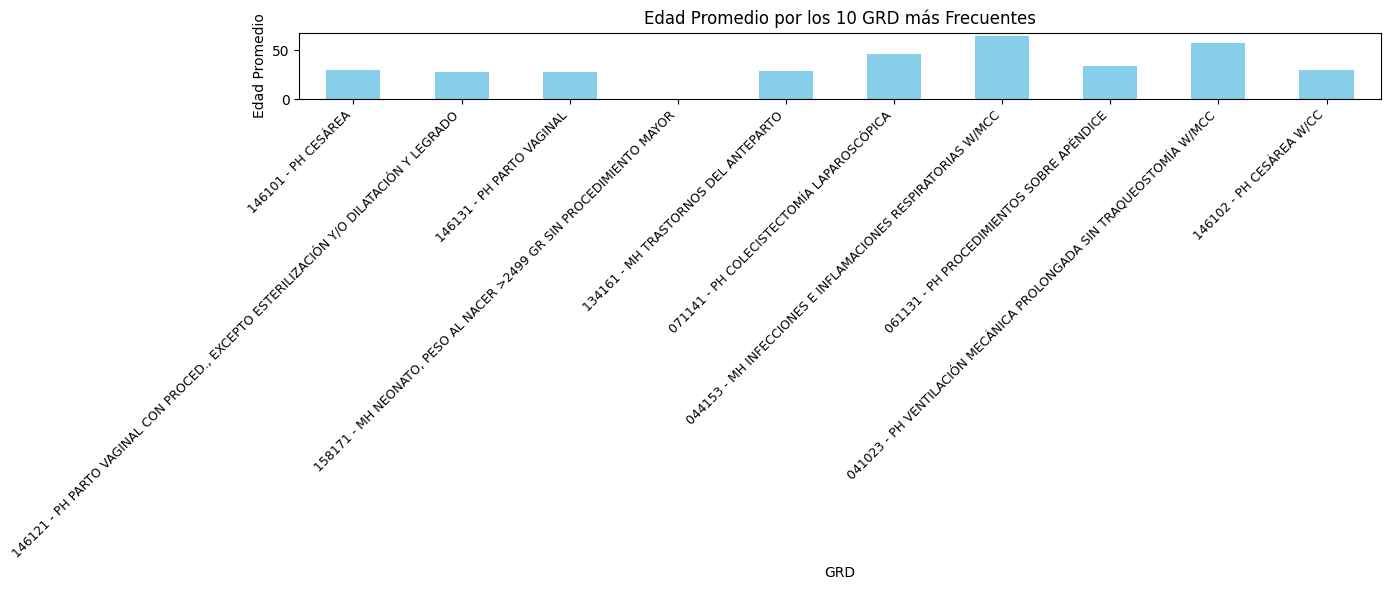

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#  Cargar el dataset principal y la tabla maestra
df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")
archivo_excel = "Tablas maestras bases GRD.xlsx"
xls = pd.ExcelFile(archivo_excel)
maestra_df = pd.read_excel(xls, sheet_name="IR - GRD")

# Asegurar tipos de datos como texto para el merge
df['GRD'] = df['GRD'].astype(str)
maestra_df['IR- GRD'] = maestra_df['IR- GRD'].astype(str)
df_merged = df.merge(maestra_df, how='left', left_on='GRD', right_on='IR- GRD')

#  1. Histograma de edades
plt.figure(figsize=(10, 5))
sns.histplot(df_merged["Edad en años"], bins=20, kde=True, color='teal')
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

#  2. Boxplot de edad por sexo
plt.figure(figsize=(8, 5))
sns.boxplot(x="Sexo (Desc)", y="Edad en años", data=df_merged, palette="Set2")
plt.title("Distribución de Edad por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Edad")
plt.tight_layout()
plt.show()

# Top 10 GRD más frecuentes
top_10_grd = df_merged['GRD'].value_counts().nlargest(10).index
df_top_10 = df_merged[df_merged['GRD'].isin(top_10_grd)]

#  3. Boxplot de edad por GRD
plt.figure(figsize=(14, 6))
sns.boxplot(x="GRD", y="Edad en años", data=df_top_10, order=top_10_grd, palette="pastel")
plt.title("Distribución de Edad por los 10 GRD más Frecuentes")
plt.xlabel("GRD")
plt.ylabel("Edad")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

#  4. Conteo por GRD
plt.figure(figsize=(14, 6))
sns.countplot(x="GRD", data=df_top_10, order=top_10_grd, palette="muted")
plt.title("Conteo de Pacientes por los 10 GRD más Frecuentes")
plt.xlabel("GRD")
plt.ylabel("Conteo de Pacientes")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

#  5. Conteo por sexo
plt.figure(figsize=(6, 4))
sns.countplot(x="Sexo (Desc)", data=df_merged, palette="coolwarm")
plt.title("Conteo de Pacientes por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Conteo")
plt.tight_layout()
plt.show()

#  6. Edad promedio por GRD
edad_promedio_por_grd = df_top_10.groupby("GRD")["Edad en años"].mean().loc[top_10_grd]

plt.figure(figsize=(14, 6))
edad_promedio_por_grd.plot(kind="bar", color='skyblue')
plt.title("Edad Promedio por los 10 GRD más Frecuentes")
plt.xlabel("GRD")
plt.ylabel("Edad Promedio")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()


Justificación de características:

Se seleccionaron como variables de entrada los diagnósticos principales y secundarios, edad y sexo, dado que están directamente relacionados con el tipo de atención médica y, por lo tanto, influyen en el agrupador GRD.
Como variable de salida se utilizó el código GRD, en formato categórico, ya que es el objetivo del proyecto

<ipython-input-8-2d1a6da56c61>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias, y=features, palette="viridis")


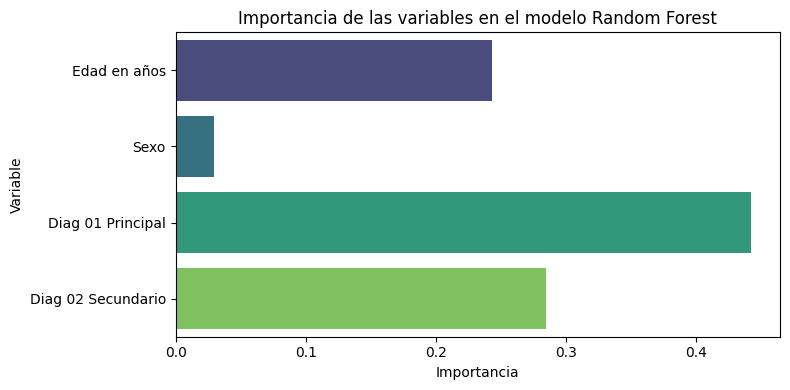

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")


vars_entrada = [
    "Edad en años",
    "Sexo (Desc)",
    "Diag 01 Principal (cod+des)",
    "Diag 02 Secundario (cod+des)"
]

df_modelo = df[vars_entrada + ["GRD"]].dropna()


df_modelo["Sexo"] = df_modelo["Sexo (Desc)"].map({"Hombre": 0, "Mujer": 1})

le_diag1 = LabelEncoder()
le_diag2 = LabelEncoder()
df_modelo["Diag 01 Principal"] = le_diag1.fit_transform(df_modelo["Diag 01 Principal (cod+des)"].astype(str))
df_modelo["Diag 02 Secundario"] = le_diag2.fit_transform(df_modelo["Diag 02 Secundario (cod+des)"].astype(str))


le_grd = LabelEncoder()
y = le_grd.fit_transform(df_modelo["GRD"])
X = df_modelo[["Edad en años", "Sexo", "Diag 01 Principal", "Diag 02 Secundario"]]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

importancias = clf.feature_importances_
features = X.columns

plt.figure(figsize=(8, 4))
sns.barplot(x=importancias, y=features, palette="viridis")
plt.title("Importancia de las variables en el modelo Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()



In [ ]:
    # Análisis de desempeño del modelo (tablas y/o gráficos).
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")

vars_entrada = [
    "Edad en años",
    "Sexo (Desc)",
    "Diag 01 Principal (cod+des)",
    "Diag 02 Secundario (cod+des)"
]
top_grd = df["GRD"].value_counts().nlargest(10).index
df = df[df["GRD"].isin(top_grd)]

df_modelo = df[vars_entrada + ["GRD"]].dropna()

df_modelo["Sexo"] = df_modelo["Sexo (Desc)"].map({"Hombre": 0, "Mujer": 1})
le_diag1 = LabelEncoder()
le_diag2 = LabelEncoder()
df_modelo["Diag 01 Principal"] = le_diag1.fit_transform(df_modelo["Diag 01 Principal (cod+des)"].astype(str))
df_modelo["Diag 02 Secundario"] = le_diag2.fit_transform(df_modelo["Diag 02 Secundario (cod+des)"].astype(str))

le_grd = LabelEncoder()
y = le_grd.fit_transform(df_modelo["GRD"])
X = df_modelo[["Edad en años", "Sexo", "Diag 01 Principal", "Diag 02 Secundario"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print(" Clasificación - Métricas por clase:")
clases_presentes = np.unique(y_test)
nombres_presentes = le_grd.inverse_transform(clases_presentes)
print(classification_report(
    y_test,
    clf.predict(X_test),
    labels=clases_presentes,
    target_names=nombres_presentes
))

cm = confusion_matrix(y_test, clf.predict(X_test), labels=clases_presentes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_presentes)

plt.figure(figsize=(10, 8))
disp.plot(cmap="viridis", xticks_rotation=45, colorbar=False)
plt.title("Matriz de Confusión - Random Forest (Top 10 GRD)")
plt.tight_layout()
plt.show()




análisis:

Exactitud global (Accuracy)
Accuracy: 0.85 (85%)

Indica que el modelo clasifica correctamente el 85% de los casos del conjunto de prueba. Es un muy buen resultado considerando que se trata de una clasificación multiclase con 10 categorías distintas.

Métricas por clase (GRD)
A continuación se analizan las clases más destacadas, con énfasis en los extremos de desempeño:


GRD | Clase resumida | Precision | Recall | F1-score | Soporte
061131 | Apéndice | 0.99 | 1.00 | 0.99 | 73
158171 | Recién nacido sin proc. mayor | 0.99 | 1.00 | 1.00 | 117
146101 | Cesárea | 0.76 | 0.87 | 0.81 | 254
146102 | Cesárea c/complicación | 0.51 | 0.28 | 0.37 | 74
041023 | Ventilación mecánica | 0.55 | 0.70 | 0.62 | 60

 Fortalezas
Alto rendimiento en GRD quirúrgicos simples, como:

Procedimientos sobre apéndice (F1=0.99)

Colecistectomía laparoscópica (F1=0.97)

GRD neonatales se predicen de forma casi perfecta (F1=1.00).

El modelo maneja bien las clases comunes y con datos bien diferenciados (alto soporte).


Debilidades
GRD 146102 (Cesárea con complicaciones) presenta bajo recall (0.28), indicando que:

Se confunde frecuentemente con otras cesáreas o diagnósticos obstétricos.

Podría tener características clínicas similares en las variables utilizadas.

También hay confusiones entre GRD relacionados al parto y embarazo, por ejemplo:

146101 (Cesárea) vs 146102 (Cesárea con complicaciones)

146121 (Parto vaginal con procedimientos) vs 146131 (Parto vaginal)

síntesis

El modelo aprende bien patrones clínicos claros y repetitivos (p.ej., apendicitis, neonatos).

Tiene dificultades cuando las clases se solapan clínica o procedimentalmente y las variables usadas (edad, sexo, diagnósticos) no capturan suficiente detalle.

In [41]:
# Resultados del entrenamiento del modelo y justificación de la elección

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             auc,
                             multilabel_confusion_matrix,
                             classification_report)


df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")


top_grd = df["GRD"].value_counts().nlargest(10).index
df = df[df["GRD"].isin(top_grd)]


vars_entrada = [
    "Edad en años",
    "Sexo (Desc)",
    "Diag 01 Principal (cod+des)",
    "Diag 02 Secundario (cod+des)"
]
df_modelo = df[vars_entrada + ["GRD"]].dropna()


df_modelo["Sexo"] = df_modelo["Sexo (Desc)"].map({"Hombre": 0, "Mujer": 1})

le_diag1 = LabelEncoder()
le_diag2 = LabelEncoder()
df_modelo["Diag 01 Principal"] = le_diag1.fit_transform(df_modelo["Diag 01 Principal (cod+des)"].astype(str))
df_modelo["Diag 02 Secundario"] = le_diag2.fit_transform(df_modelo["Diag 02 Secundario (cod+des)"].astype(str))

le_grd = LabelEncoder()
y = le_grd.fit_transform(df_modelo["GRD"])
X = df_modelo[["Edad en años", "Sexo", "Diag 01 Principal", "Diag 02 Secundario"]]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred_rf = clf.predict(X_test)

log_clf = LogisticRegression(max_iter=2000, random_state=42)
log_clf.fit(X_train, y_train)
y_pred_log = log_clf.predict(X_test)


knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
y_pred_knn = knn_clf.predict(X_test)


grd_labels = le_grd.inverse_transform(np.unique(y_test))


print("Regresión Logística:")
print(classification_report(y_test, y_pred_log, target_names=grd_labels, zero_division=0))

print("Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=grd_labels, zero_division=0))

print("K-Nearest Neighbors (KNN):")
print(classification_report(y_test, y_pred_knn, target_names=grd_labels, zero_division=0))

print(" Accuracy Regresión Logística:", round(accuracy_score(y_test, y_pred_log), 4))
print(" Accuracy Random Forest:", round(accuracy_score(y_test, y_pred_rf), 4))
print(" Accuracy KNN:", round(accuracy_score(y_test, y_pred_knn), 4))


Regresión Logística:
                                                                                        precision    recall  f1-score   support

                   041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC       0.27      0.23      0.25        60
                           044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC       0.82      0.73      0.77       110
                                             061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE       0.56      0.62      0.58        73
                                             071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA       0.55      0.53      0.54       100
                                                  134161 - MH TRASTORNOS DEL ANTEPARTO       0.76      0.19      0.31        98
                                                                   146101 - PH CESÁREA       0.54      0.78      0.64       254
                                                              146102 - PH CESÁREA 

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


clf1 = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
clf1.fit(X_train, y_train)

OneVsRestClassifier(estimator=RandomForestClassifier(random_state=42))

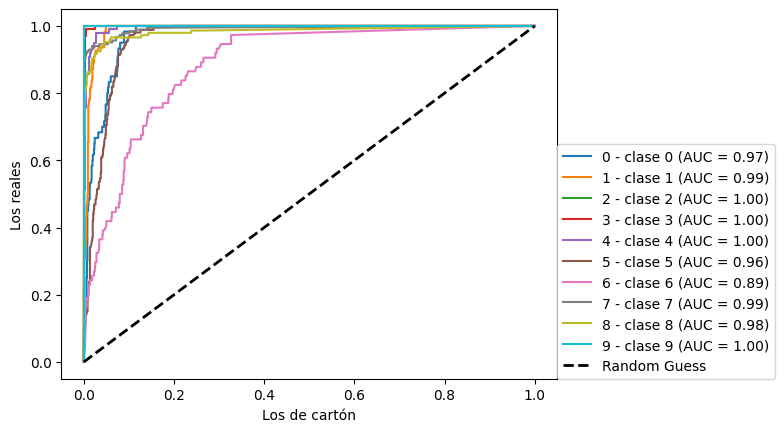

In [43]:
# La(s) curva(s) para multiclase
probs = {}
fpr = {}
tpr = {}
roc_auc = {}
# Ignoraremos los umbrales ahora

# Convertir y_test a un array bidimensional para la clasificación multiclase
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=clf1.classes_)
n_classes = y_test_bin.shape[1]

for i, label in enumerate(clf1.classes_):
    probs[i] = clf1.predict_proba(X_test)[:, i]
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[i])  # Usar y_test_bin
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(fpr[i], tpr[i],
             label=f'{label} - clase {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlabel("Los de cartón")
plt.ylabel("Los reales")
# La leyenda por fuera
plt.legend(loc=(1, 0))
plt.show()

In [44]:
log_clf1 = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
log_clf1.fit(X_train, y_train)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000,
                                                 random_state=42))

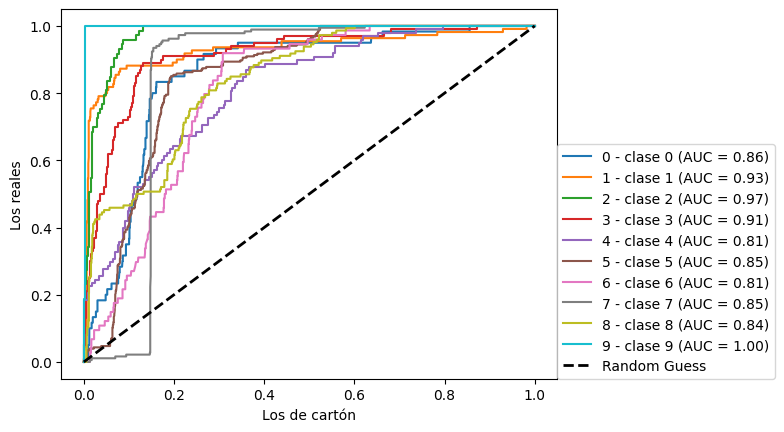

In [45]:
# La(s) curva(s) para multiclase
probs = {}
fpr = {}
tpr = {}
roc_auc = {}
# Ignoraremos los umbrales ahora

# Convertir y_test a un array bidimensional para la clasificación multiclase
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=log_clf1.classes_)
n_classes = y_test_bin.shape[1]

for i, label in enumerate(log_clf1.classes_):
    probs[i] = log_clf1.predict_proba(X_test)[:, i]
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[i])  # Usar y_test_bin
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(fpr[i], tpr[i],
             label=f'{label} - clase {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlabel("Los de cartón")
plt.ylabel("Los reales")
# La leyenda por fuera
plt.legend(loc=(1, 0))
plt.show()

In [ ]:
knn_clf1 = KNeighborsClassifier(n_neighbors=5)
knn_clf1.fit(X_train, y_train)

KNeighborsClassifier()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning

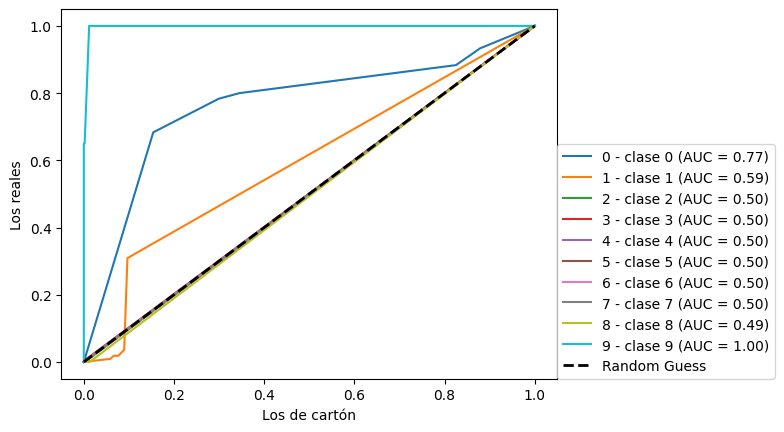

In [46]:
# La(s) curva(s) para multiclase
probs = {}
fpr = {}
tpr = {}
roc_auc = {}
# Ignoraremos los umbrales ahora

# Convertir y_test a un array bidimensional para la clasificación multiclase
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=knn_clf1.classes_)
n_classes = y_test_bin.shape[1]

for i, label in enumerate(knn_clf1.classes_):
    probs[i] = knn_clf1.predict_proba(X_test)[:, i]
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[i])  # Usar y_test_bin
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(fpr[i], tpr[i],
             label=f'{label} - clase {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlabel("Los de cartón")
plt.ylabel("Los reales")
# La leyenda por fuera
plt.legend(loc=(1, 0))
plt.show()

 Clasificación - Métricas por clase:
                                                                                        precision    recall  f1-score   support

                   041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC       0.55      0.70      0.62        60
                           044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC       0.87      0.70      0.77       110
                                             061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE       0.99      1.00      0.99        73
                                             071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA       0.95      0.98      0.97       100
                                                  134161 - MH TRASTORNOS DEL ANTEPARTO       0.85      0.86      0.85        98
                                                                   146101 - PH CESÁREA       0.76      0.87      0.81       254
                                                              1461

<ipython-input-33-458ca69786aa>:54: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1000x800 with 0 Axes>

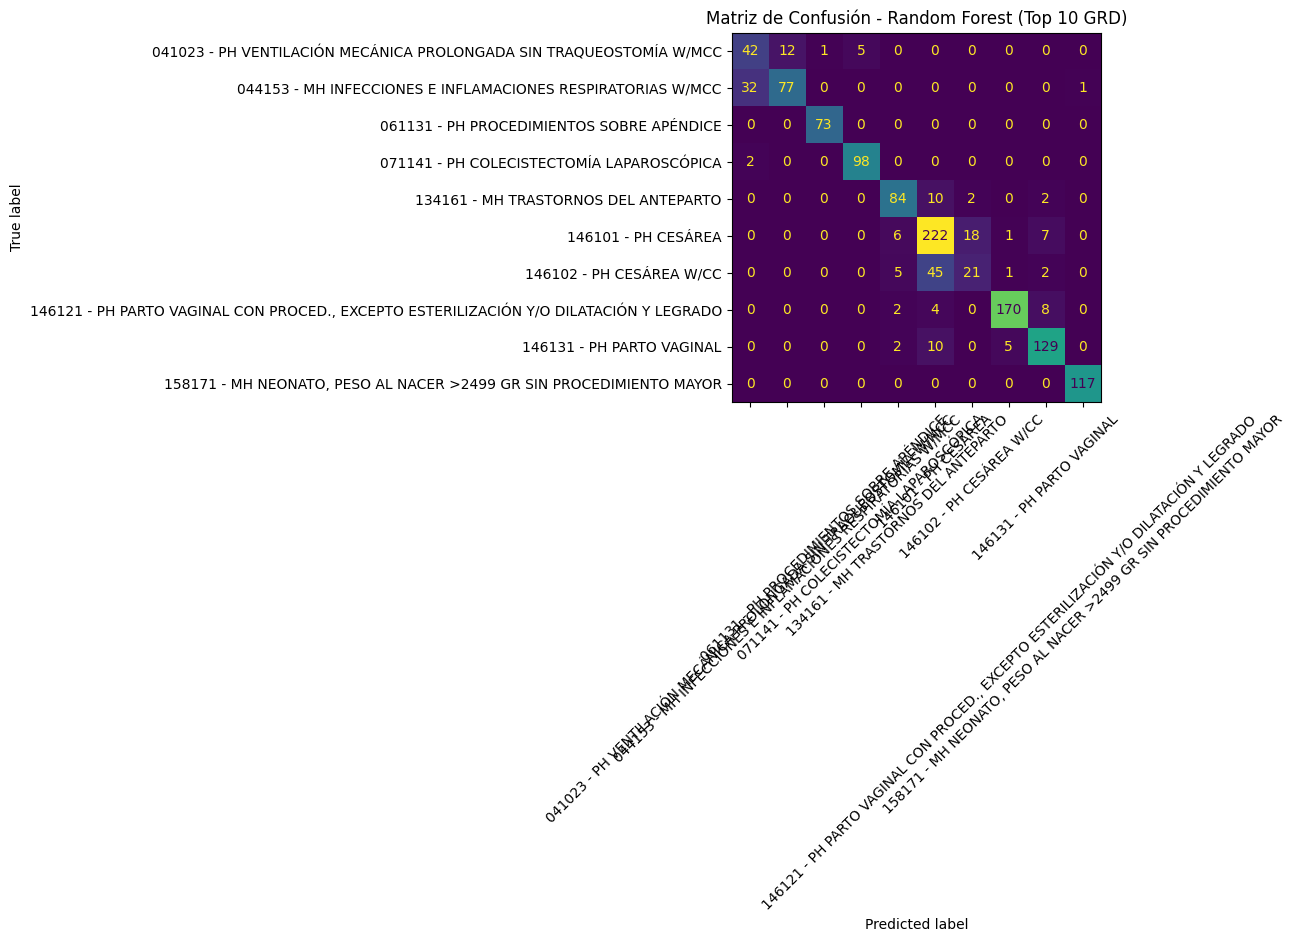

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")

vars_entrada = [
    "Edad en años",
    "Sexo (Desc)",
    "Diag 01 Principal (cod+des)",
    "Diag 02 Secundario (cod+des)"
]
top_grd = df["GRD"].value_counts().nlargest(10).index
df = df[df["GRD"].isin(top_grd)]

df_modelo = df[vars_entrada + ["GRD"]].dropna()

df_modelo["Sexo"] = df_modelo["Sexo (Desc)"].map({"Hombre": 0, "Mujer": 1})
le_diag1 = LabelEncoder()
le_diag2 = LabelEncoder()
df_modelo["Diag 01 Principal"] = le_diag1.fit_transform(df_modelo["Diag 01 Principal (cod+des)"].astype(str))
df_modelo["Diag 02 Secundario"] = le_diag2.fit_transform(df_modelo["Diag 02 Secundario (cod+des)"].astype(str))

le_grd = LabelEncoder()
y = le_grd.fit_transform(df_modelo["GRD"])
X = df_modelo[["Edad en años", "Sexo", "Diag 01 Principal", "Diag 02 Secundario"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print(" Clasificación - Métricas por clase:")
clases_presentes = np.unique(y_test)
nombres_presentes = le_grd.inverse_transform(clases_presentes)
print(classification_report(
    y_test,
    clf.predict(X_test),
    labels=clases_presentes,
    target_names=nombres_presentes
))

cm = confusion_matrix(y_test, clf.predict(X_test), labels=clases_presentes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_presentes)

plt.figure(figsize=(10, 8))
disp.plot(cmap="viridis", xticks_rotation=45, colorbar=False)
plt.title("Matriz de Confusión - Random Forest (Top 10 GRD)")
plt.tight_layout()
plt.show()


Regresión Logística:
                                                                                        precision    recall  f1-score   support

                   041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC       0.27      0.23      0.25        60
                           044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC       0.82      0.73      0.77       110
                                             061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE       0.56      0.62      0.58        73
                                             071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA       0.55      0.53      0.54       100
                                                  134161 - MH TRASTORNOS DEL ANTEPARTO       0.76      0.19      0.31        98
                                                                   146101 - PH CESÁREA       0.54      0.78      0.64       254
                                                              146102 - PH CESÁREA 

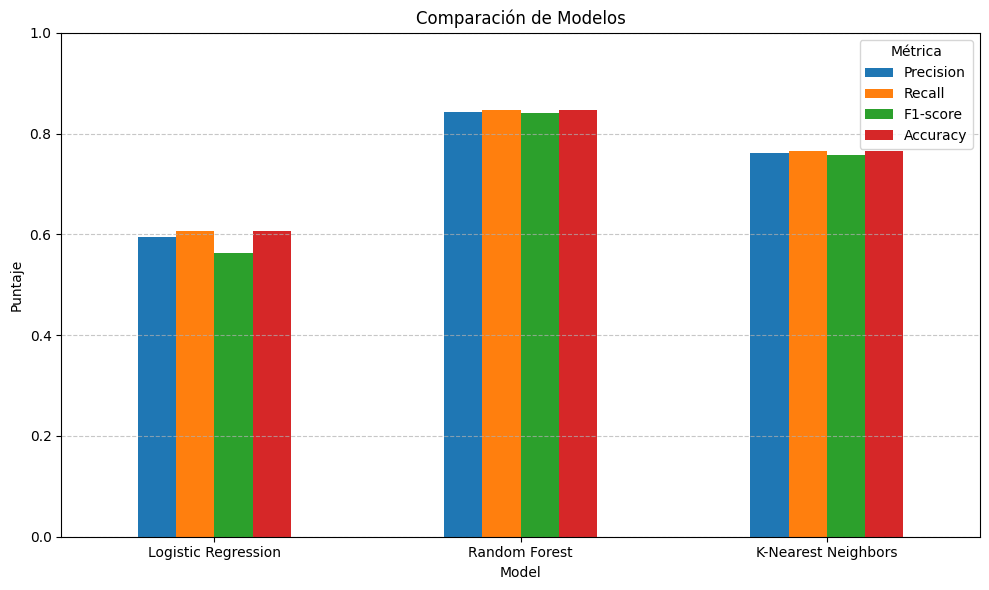

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support  # <--- esta línea es clave

# Cargar datos
df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")

# Filtrar los 10 GRD más comunes
top_grd = df["GRD"].value_counts().nlargest(10).index
df = df[df["GRD"].isin(top_grd)]

# Selección de variables
vars_entrada = [
    "Edad en años",
    "Sexo (Desc)",
    "Diag 01 Principal (cod+des)",
    "Diag 02 Secundario (cod+des)"
]
df_modelo = df[vars_entrada + ["GRD"]].dropna()

# Codificación de variables categóricas
df_modelo["Sexo"] = df_modelo["Sexo (Desc)"].map({"Hombre": 0, "Mujer": 1})
le_diag1 = LabelEncoder()
le_diag2 = LabelEncoder()
df_modelo["Diag 01 Principal"] = le_diag1.fit_transform(df_modelo["Diag 01 Principal (cod+des)"].astype(str))
df_modelo["Diag 02 Secundario"] = le_diag2.fit_transform(df_modelo["Diag 02 Secundario (cod+des)"].astype(str))

# Etiquetas y características
le_grd = LabelEncoder()
y = le_grd.fit_transform(df_modelo["GRD"])
X = df_modelo[["Edad en años", "Sexo", "Diag 01 Principal", "Diag 02 Secundario"]]

# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Modelos
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred_rf = clf.predict(X_test)

log_clf = LogisticRegression(max_iter=2000, random_state=42)
log_clf.fit(X_train, y_train)
y_pred_log = log_clf.predict(X_test)

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
y_pred_knn = knn_clf.predict(X_test)

# Reportes
grd_labels = le_grd.inverse_transform(np.unique(y_test))

print("Regresión Logística:")
print(classification_report(y_test, y_pred_log, target_names=grd_labels, zero_division=0))

print("Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=grd_labels, zero_division=0))

print("K-Nearest Neighbors (KNN):")
print(classification_report(y_test, y_pred_knn, target_names=grd_labels, zero_division=0))

print(" Accuracy Regresión Logística:", round(accuracy_score(y_test, y_pred_log), 4))
print(" Accuracy Random Forest:", round(accuracy_score(y_test, y_pred_rf), 4))
print(" Accuracy KNN:", round(accuracy_score(y_test, y_pred_knn), 4))

# Función para graficar métricas
def graficar_metricas_modelos(y_test, y_pred_log, y_pred_rf, y_pred_knn):
    metrics_log = precision_recall_fscore_support(y_test, y_pred_log, average='weighted', zero_division=0)
    metrics_rf = precision_recall_fscore_support(y_test, y_pred_rf, average='weighted', zero_division=0)
    metrics_knn = precision_recall_fscore_support(y_test, y_pred_knn, average='weighted', zero_division=0)

    results = pd.DataFrame({
        "Model": ["Logistic Regression", "Random Forest", "K-Nearest Neighbors"],
        "Precision": [metrics_log[0], metrics_rf[0], metrics_knn[0]],
        "Recall": [metrics_log[1], metrics_rf[1], metrics_knn[1]],
        "F1-score": [metrics_log[2], metrics_rf[2], metrics_knn[2]],
        "Accuracy": [
            accuracy_score(y_test, y_pred_log),
            accuracy_score(y_test, y_pred_rf),
            accuracy_score(y_test, y_pred_knn)
        ]
    }).set_index("Model")

    # Graficar
    fig, ax = plt.subplots(figsize=(10, 6))
    results.plot(kind="bar", ax=ax)
    plt.title("Comparación de Modelos")
    plt.ylabel("Puntaje")
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(title="Métrica")
    plt.tight_layout()
    plt.show()

# Llamar a la función para graficar
graficar_metricas_modelos(y_test, y_pred_log, y_pred_rf, y_pred_knn)

 Clasificación - Métricas por clase:
                                                                                        precision    recall  f1-score   support

                   041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC       0.55      0.70      0.62        60
                           044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC       0.87      0.70      0.77       110
                                             061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE       0.99      1.00      0.99        73
                                             071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA       0.95      0.98      0.97       100
                                                  134161 - MH TRASTORNOS DEL ANTEPARTO       0.85      0.86      0.85        98
                                                                   146101 - PH CESÁREA       0.76      0.87      0.81       254
                                                              1461

<ipython-input-35-aa0036b81e13>:62: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1000x800 with 0 Axes>

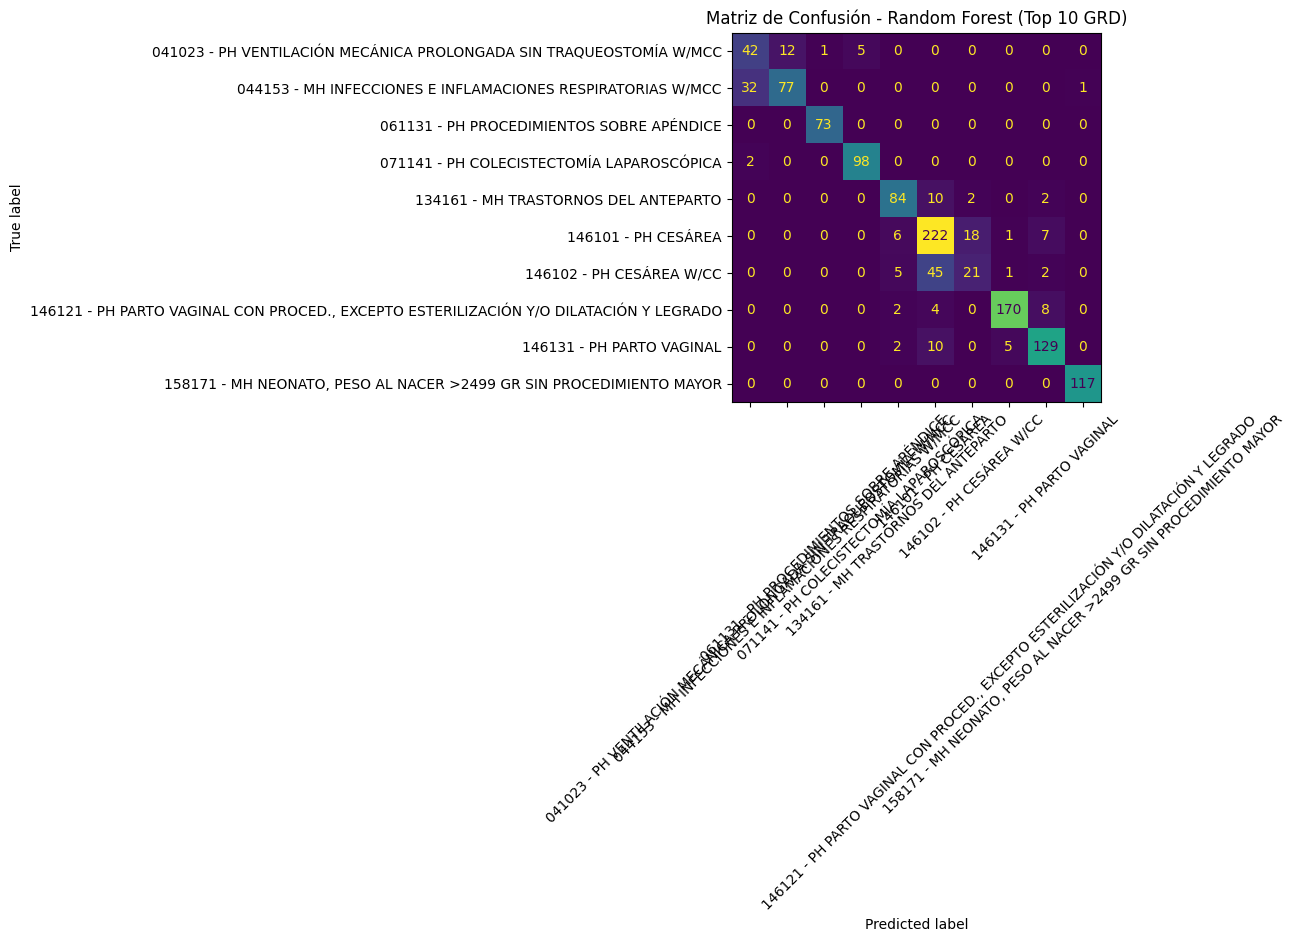


🔹 Predicción 1:
   - Edad: 79 | Sexo: Hombre
   - Diag. Principal: K85.9 - Pancreatitis aguda, no especificada
   - Diag. Secundario: R65.1 - Sindrome de Respuesta inflamatora sistémica de origen infeccioso con falla orgánica
 GRD predicho: 041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC


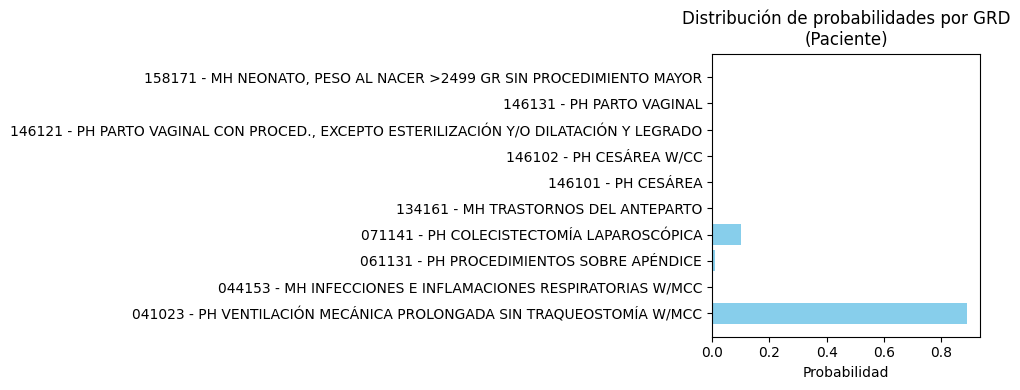

   -  GRD real:     041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC
   -  GRD predicho: 041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC
   -  Métricas para este GRD → Precision: 0.55, Recall: 0.70, F1-Score: 0.62

🔹 Predicción 2:
   - Edad: 34 | Sexo: Mujer
   - Diag. Principal: O62.1 - Inercia uterina secundaria
   - Diag. Secundario: O36.6 - Atención materna por crecimiento fetal excesivo
 GRD predicho: 146131 - PH PARTO VAGINAL


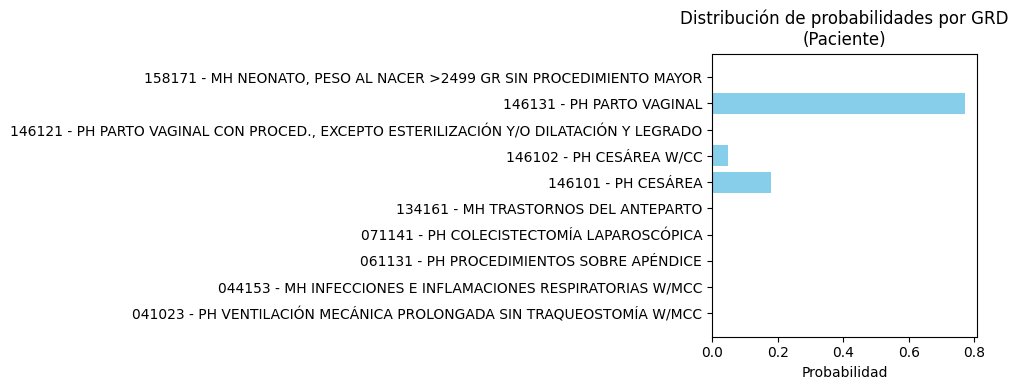

   -  GRD real:     146131 - PH PARTO VAGINAL
   -  GRD predicho: 146131 - PH PARTO VAGINAL
   -  Métricas para este GRD → Precision: 0.87, Recall: 0.88, F1-Score: 0.88

🔹 Predicción 3:
   - Edad: 21 | Sexo: Mujer
   - Diag. Principal: O80.0 - Parto único espontáneo, presentación cefálica de vértice
   - Diag. Secundario: O62.3 - Trabajo de parto precipitado
 GRD predicho: 146131 - PH PARTO VAGINAL


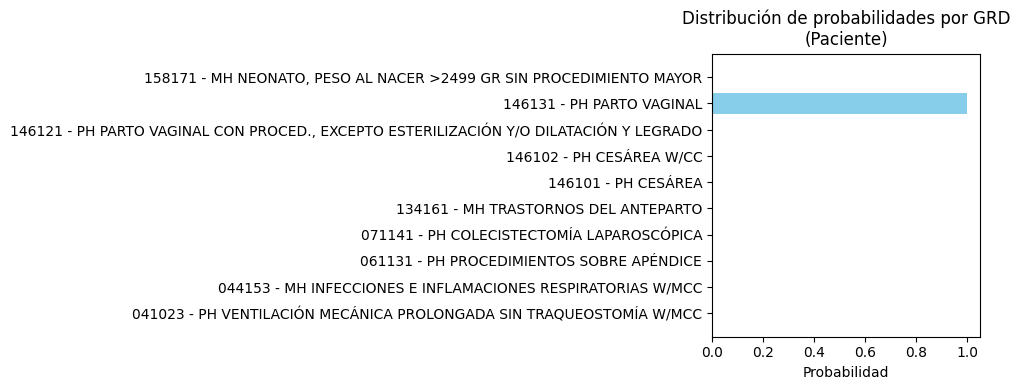

   -  GRD real:     146131 - PH PARTO VAGINAL
   -  GRD predicho: 146131 - PH PARTO VAGINAL
   -  Métricas para este GRD → Precision: 0.87, Recall: 0.88, F1-Score: 0.88


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import random

# 1. Cargar dataset
df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")

# 2. Variables a usar
vars_entrada = [
    "Edad en años",
    "Sexo (Desc)",
    "Diag 01 Principal (cod+des)",
    "Diag 02 Secundario (cod+des)"
]

# 3. Filtrar top 10 GRD
top_grd = df["GRD"].value_counts().nlargest(10).index
df = df[df["GRD"].isin(top_grd)]

# 4. Preprocesamiento
df_modelo = df[vars_entrada + ["GRD"]].dropna()
df_modelo["Sexo"] = df_modelo["Sexo (Desc)"].map({"Hombre": 0, "Mujer": 1})

le_diag1 = LabelEncoder()
le_diag2 = LabelEncoder()
df_modelo["Diag 01 Principal"] = le_diag1.fit_transform(df_modelo["Diag 01 Principal (cod+des)"].astype(str))
df_modelo["Diag 02 Secundario"] = le_diag2.fit_transform(df_modelo["Diag 02 Secundario (cod+des)"].astype(str))

le_grd = LabelEncoder()
y = le_grd.fit_transform(df_modelo["GRD"])
X = df_modelo[["Edad en años", "Sexo", "Diag 01 Principal", "Diag 02 Secundario"]]

# 5. División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 6. Entrenar modelo
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 7. Evaluación del modelo
print(" Clasificación - Métricas por clase:")
clases_presentes = np.unique(y_test)
nombres_presentes = le_grd.inverse_transform(clases_presentes)
print(classification_report(
    y_test,
    clf.predict(X_test),
    labels=clases_presentes,
    target_names=nombres_presentes
))

# 8. Matriz de confusión
cm = confusion_matrix(y_test, clf.predict(X_test), labels=clases_presentes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_presentes)
plt.figure(figsize=(10, 8))
disp.plot(cmap="viridis", xticks_rotation=45, colorbar=False)
plt.title("Matriz de Confusión - Random Forest (Top 10 GRD)")
plt.tight_layout()
plt.show()

# 9. Función de predicción robusta
def predecir_grd(paciente, modelo, le_grd, le_diag1, le_diag2, mostrar_probas=False):
    df = pd.DataFrame([paciente])
    df["Sexo"] = df["Sexo (Desc)"].map({"Hombre": 0, "Mujer": 1})

    # Validar diagnósticos
    if paciente["Diag 01 Principal (cod+des)"] not in le_diag1.classes_:
        print(" Diagnóstico principal no reconocido:", paciente["Diag 01 Principal (cod+des)"])
        return None
    if paciente["Diag 02 Secundario (cod+des)"] not in le_diag2.classes_:
        print(" Diagnóstico secundario no reconocido:", paciente["Diag 02 Secundario (cod+des)"])
        return None

    df["Diag 01 Principal"] = le_diag1.transform(df["Diag 01 Principal (cod+des)"].astype(str))
    df["Diag 02 Secundario"] = le_diag2.transform(df["Diag 02 Secundario (cod+des)"].astype(str))

    X_nuevo = df[["Edad en años", "Sexo", "Diag 01 Principal", "Diag 02 Secundario"]]
    y_pred = modelo.predict(X_nuevo)[0]
    grd_predicho = le_grd.inverse_transform([y_pred])[0]

    print(f" GRD predicho: {grd_predicho}")

    if mostrar_probas:
        probas = modelo.predict_proba(X_nuevo)[0]
        clases = le_grd.inverse_transform(np.arange(len(probas)))

        # Mostrar gráfico de barras
        plt.figure(figsize=(10, 4))
        plt.barh(clases, probas, color="skyblue")
        plt.xlabel("Probabilidad")
        plt.title(f"Distribución de probabilidades por GRD\n(Paciente)")
        plt.tight_layout()
        plt.show()

    return grd_predicho

# 10. Obtener clasificación como dict
y_pred = clf.predict(X_test)
reporte = classification_report(
    y_test,
    y_pred,
    labels=clases_presentes,
    target_names=nombres_presentes,
    output_dict=True
)

# 11. Predicciones random con gráfico
def predicciones_random(df_modelo, modelo, le_grd, le_diag1, le_diag2, reporte_dict, n=3):
    muestras = df_modelo.sample(n)

    for i, (_, paciente) in enumerate(muestras.iterrows(), 1):
        paciente_dict = {
            "Edad en años": paciente["Edad en años"],
            "Sexo (Desc)": "Mujer" if paciente["Sexo"] == 1 else "Hombre",
            "Diag 01 Principal (cod+des)": le_diag1.inverse_transform([paciente["Diag 01 Principal"]])[0],
            "Diag 02 Secundario (cod+des)": le_diag2.inverse_transform([paciente["Diag 02 Secundario"]])[0]
        }

        grd_real = paciente["GRD"]
        print(f"\n🔹 Predicción {i}:")
        print(f"   - Edad: {paciente_dict['Edad en años']} | Sexo: {paciente_dict['Sexo (Desc)']}")
        print(f"   - Diag. Principal: {paciente_dict['Diag 01 Principal (cod+des)']}")
        print(f"   - Diag. Secundario: {paciente_dict['Diag 02 Secundario (cod+des)']}")

        grd_predicho = predecir_grd(paciente_dict, modelo, le_grd, le_diag1, le_diag2, mostrar_probas=True)

        if grd_predicho and grd_predicho in reporte_dict:
            precision = reporte_dict[grd_predicho]['precision']
            recall = reporte_dict[grd_predicho]['recall']
            f1 = reporte_dict[grd_predicho]['f1-score']
            print(f"   -  GRD real:     {grd_real}")
            print(f"   -  GRD predicho: {grd_predicho}")
            print(f"   -  Métricas para este GRD → Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}")
        else:
            print(" GRD no encontrado en métricas del modelo.")

# Llamar la función
predicciones_random(df_modelo, clf, le_grd, le_diag1, le_diag2, reporte, n=3)

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np

df = pd.read_csv("dataset_elpino.csv", sep=";", encoding="utf-8")
archivo_excel = "Tablas maestras bases GRD.xlsx"
xls = pd.ExcelFile(archivo_excel)
maestra_df = pd.read_excel(xls, sheet_name="IR - GRD")

df['GRD'] = df['GRD'].astype(str)
maestra_df['IR- GRD'] = maestra_df['IR- GRD'].astype(str)

df_merged = df.merge(maestra_df, how='left', left_on='GRD', right_on='IR- GRD')

vars_entrada = [
    'Edad en años',
    'Sexo (Desc)',
    'Diag 01 Principal (cod+des)',
    'Diag 02 Secundario (cod+des)'
]

df_modelo = df_merged[vars_entrada + ['GRD']].dropna()

df_modelo['Sexo'] = df_modelo['Sexo (Desc)'].map({'Hombre': 0, 'Mujer': 1})

le_diag_principal = LabelEncoder()
le_diag_secundario = LabelEncoder()

df_modelo['Diag 01 Principal (cod+des)'] = le_diag_principal.fit_transform(
    df_modelo['Diag 01 Principal (cod+des)'].astype(str)
)
df_modelo['Diag 02 Secundario (cod+des)'] = le_diag_secundario.fit_transform(
    df_modelo['Diag 02 Secundario (cod+des)'].astype(str)
)

le_grd = LabelEncoder()
y = le_grd.fit_transform(df_modelo['GRD'])

X = df_modelo[['Edad en años', 'Sexo', 'Diag 01 Principal (cod+des)', 'Diag 02 Secundario (cod+des)']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

unique_labels = np.unique(y_test)

print("Resultados del modelo Random Forest")
print(classification_report(
    y_test,
    preds,
    labels=unique_labels,
    target_names=le_grd.inverse_transform(unique_labels)
))


Resultados del modelo Random Forest
                                                                                                           precision    recall  f1-score   support

                                                    014103 - MH ENFERMEDADES Y TRASTORNOS ESPINALES W/MCC       0.00      0.00      0.00         1
                           014112 - MH ENFERMEDADES DEGENERATIVAS Y NEOPLÁSICAS DEL SISTEMA NERVIOSO W/CC       0.00      0.00      0.00         2
                                                        014131 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA       0.00      0.00      0.00         2
                                                   014132 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA W/CC       0.29      0.40      0.33         5
                                                  014133 - MH HEMORRAGIA INTRACRANEAL NO TRAUMÁTICA W/MCC       0.00      0.00      0.00         6
                                                        014141 - MH ACCIDENTE CER

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
